In [1]:
from data_code.dataset_builder import build_dataset

import torch
import torch.nn as nn

In [2]:
int_emb = torch.load('data_code/INT_embeddings.pt')
rt_emb = torch.load('data_code/RT_embeddings.pt')
rn_emb = torch.load('data_code/RNaseH_embeddings.pt')
neg_emb = torch.load('data_code/negatives_embeddings.pt')
class_embeddings = {"INT": int_emb, "RT": rt_emb, "RN": rn_emb, "NEG": neg_emb}

train_loader, val_loader, class_weights, label_map = build_dataset(class_embeddings = class_embeddings, window_size= 128)

Label map: {'INT': 0, 'RT': 1, 'RN': 2, 'NEG': 3}
Train: 73, Val: 17
Train distribution: {'INT': 9, 'RT': 9, 'RN': 9, 'NEG': 46}
Class weights: {'INT': 1.252, 'RT': 1.252, 'RN': 1.252, 'NEG': 0.245}


In [3]:
class BioSequenceClassifier(nn.Module):
    def __init__(self):
        super(BioSequenceClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.model(x)

In [4]:
device = 'cuda'

In [5]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
model = BioSequenceClassifier().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01, weight_decay= 1e-5)
epochs = 20

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    num_samples = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = inputs.size(0)
        running_loss += loss.item() * batch_size
        num_samples += batch_size

    epoch_loss = running_loss / num_samples

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
                
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_acc = 100 * correct / total
        
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_acc)
        
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {epoch_loss:.4f} | "
                f"Val Loss: {val_epoch_loss:.4f} | "
                f"Val Acc: {val_acc:.2f}%")

Epoch 2/20 | Train Loss: 1.0444 | Val Loss: 0.7617 | Val Acc: 88.24%
Epoch 4/20 | Train Loss: 0.7284 | Val Loss: 0.6519 | Val Acc: 76.47%
Epoch 6/20 | Train Loss: 0.6716 | Val Loss: 0.6407 | Val Acc: 82.35%
Epoch 8/20 | Train Loss: 0.6372 | Val Loss: 0.8677 | Val Acc: 82.35%
Epoch 10/20 | Train Loss: 0.7473 | Val Loss: 0.5492 | Val Acc: 88.24%
Epoch 12/20 | Train Loss: 0.6156 | Val Loss: 0.5883 | Val Acc: 82.35%
Epoch 14/20 | Train Loss: 0.5875 | Val Loss: 0.5819 | Val Acc: 88.24%
Epoch 16/20 | Train Loss: 0.5474 | Val Loss: 0.4323 | Val Acc: 88.24%
Epoch 18/20 | Train Loss: 0.5158 | Val Loss: 0.5900 | Val Acc: 82.35%
Epoch 20/20 | Train Loss: 0.5796 | Val Loss: 0.4440 | Val Acc: 88.24%


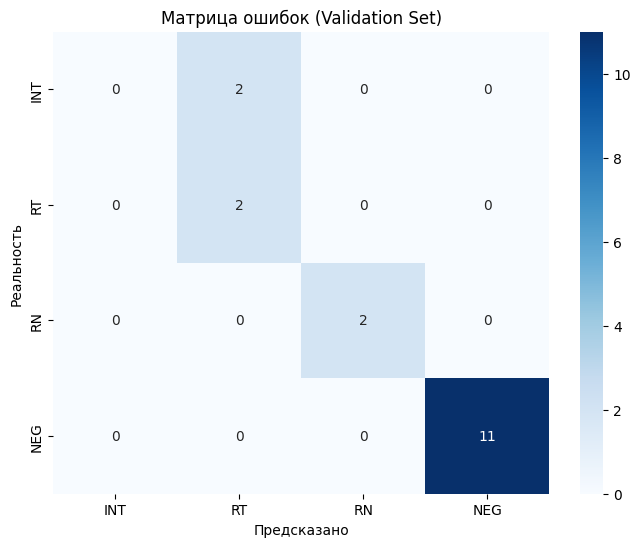

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    classes = ['INT', 'RT', 'RN', 'NEG']
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Предсказано')
    plt.ylabel('Реальность')
    plt.title('Матрица ошибок (Validation Set)')
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plot_confusion_matrix(model, val_loader, device)